In [1]:
%load_ext autoreload
%autoreload 2

import ast

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
df = pd.read_parquet("../model-building/local-assets/MERGED_LCS.parquet")
df


,time,flux,Class
KIC,,,
757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED
892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE
1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1.0488531548750866, 1.0523113529281902, 1.051...",CANDIDATE
1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",FALSE POSITIVE
1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED
...,...,...,...
202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",VARIABLE STAR
202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",VARIABLE STAR
202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",FALSE POSITIVE


In [3]:
df = df.reset_index()


In [4]:
renameMap = {
    'Class': 'class',
}

df = df.rename(columns=renameMap)


In [5]:
df = df[df['class'] != 'CANDIDATE'].copy()


In [6]:
def chooseLabel(labels):
    labels = list(labels)
    nonFp = [lab for lab in labels if lab != "FALSE POSITIVE"]

    if len(nonFp) > 0:
        # If there are multiple non-FP labels, take the most common one
        return pd.Series(nonFp).mode().iloc[0]

    # If all labels are FALSE POSITIVE, keep one of them
    return pd.Series(labels).mode().iloc[0]


df = (
    df.groupby("KIC", as_index=False)
        .agg({
            "time": "first",
            "flux": "first",
            "class": chooseLabel
        })
)


In [7]:
def encodeLabels(df):
    """
    Function to encode the labels in the 'Class' feature of a given dataframe df.
    """
    le = LabelEncoder()
    y = le.fit_transform(df["class"].values)
    df = df.copy()
    df["label"] = y

    return df, le


In [8]:
df, le = encodeLabels(df)
df


,KIC,time,flux,class,label
0,757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED,0
1,892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE,2
2,1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",ECLIPSING BINARY STAR,1
3,1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED,0
4,1027438,"[131.51268857505056, 131.53312328704487, 131.5...","[1.0649623994019086, 1.0653504391733866, 1.065...",FALSE POSITIVE,2
...,...,...,...,...,...
15601,202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",VARIABLE STAR,3
15602,202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",VARIABLE STAR,3
15603,202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",FALSE POSITIVE,2
15604,202140094,"[1940.0088592208049, 1940.029290861763, 1940.0...","[1.008090615272522, 1.0085946321487427, 1.0099...",FALSE POSITIVE,2


In [9]:
def to_1d_float_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=np.float32).reshape(-1)


def clean_time_flux(time, flux):
    time = to_1d_float_array(time)
    flux = to_1d_float_array(flux)

    if len(time) == 0 or len(flux) == 0:
        return None, None

    n = min(len(time), len(flux))
    time = time[:n]
    flux = flux[:n]

    mask = np.isfinite(time) & np.isfinite(flux)
    time = time[mask]
    flux = flux[mask]

    if len(time) < 2:
        return None, None

    return time, flux


def normalize_flux(flux):
    flux = np.asarray(flux, dtype=np.float32)

    if len(flux) == 0:
        return None

    med = np.median(flux)
    if not np.isfinite(med) or med == 0:
        med = 1.0

    return flux / med - 1.0


def clip_flux(flux, clip_sigma=5.0):
    mu = np.mean(flux)
    sd = np.std(flux)

    if np.isfinite(sd) and sd > 0:
        lo, hi = mu - clip_sigma * sd, mu + clip_sigma * sd
        return np.clip(flux, lo, hi)

    return flux


def resample_to_fixed_length(time, flux, seq_len=2000):
    if len(time) < 2:
        return None

    order = np.argsort(time)
    time = time[order]
    flux = flux[order]

    uniq_time, uniq_idx = np.unique(time, return_index=True)
    time = uniq_time
    flux = flux[uniq_idx]

    if len(time) < 2:
        return None

    t_new = np.linspace(time.min(), time.max(), seq_len)
    y_new = np.interp(t_new, time, flux).astype(np.float32)

    return y_new


def standardize_flux(flux):
    x = flux - np.mean(flux)
    std = np.std(x)

    if np.isfinite(std) and std > 0:
        x = x / std

    return x


def preprocess_light_curve(time, flux, seq_len=2000):
    time, flux = clean_time_flux(time, flux)
    if time is None:
        return None

    flux = normalize_flux(flux)
    if flux is None:
        return None

    flux = clip_flux(flux)

    x = resample_to_fixed_length(time, flux, seq_len)
    if x is None:
        return None

    x = standardize_flux(x)

    return x.astype(np.float32)


In [65]:
def preprocess_dataframe(df, seq_len=2000):
    processed_rows = []
    
    for _, row in df.iterrows():
        x = preprocess_light_curve(row["time"], row["flux"], seq_len=seq_len)

        if x is None:
            continue  # skip bad rows

        appendDict = {
            "KIC": row["KIC"],
            "x": x,
            "label": row["label"]
        }

        processed_rows.append(appendDict)

    return pd.DataFrame(processed_rows)


---

In [47]:
# Pick one example from the original dataframe
sample_idx = 0
row = df.iloc[sample_idx]

time_raw = to_1d_float_array(row["time"])
flux_raw = to_1d_float_array(row["flux"])

print("KIC:", row["KIC"])
print("Class:", row["class"])
print("Raw time length:", len(time_raw))
print("Raw flux length:", len(flux_raw))


KIC: 757450
Class: CONFIRMED
Raw time length: 64795
Raw flux length: 64795


In [48]:
# Step 1: clean paired time/flux values
time_clean, flux_clean = clean_time_flux(row["time"], row["flux"])

print("Cleaned time length:", None if time_clean is None else len(time_clean))
print("Cleaned flux length:", None if flux_clean is None else len(flux_clean))


Cleaned time length: 64795
Cleaned flux length: 64795


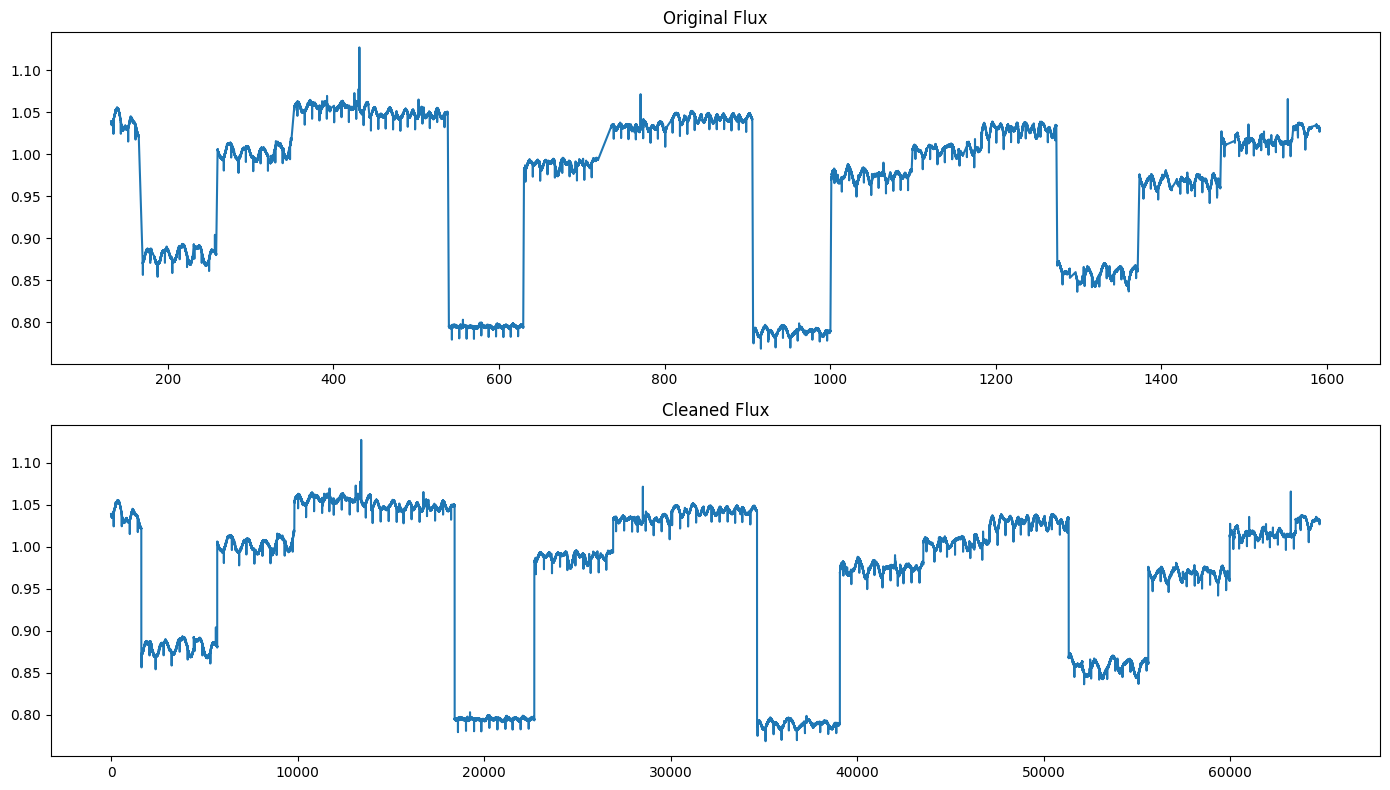

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_raw, flux_raw)
axes[0].set_title("Original Flux")

axes[1].plot(flux_clean)
axes[1].set_title("Cleaned Flux")

plt.tight_layout()
plt.show()


In [50]:
print(f"Raw time: {time_raw}\nCleaned time: {time_clean}")
print(f"\nRaw flux: {flux_raw}\nCleaned flux: {flux_clean}")


Raw time: [ 131.51271  131.53314  131.55359 ... 1590.9607  1590.9811  1591.0015 ]
Cleaned time: [ 131.51271  131.53314  131.55359 ... 1590.9607  1590.9811  1591.0015 ]

Raw flux: [1.0392151 1.0383359 1.0387748 ... 1.0313793 1.0268365 1.0311056]
Cleaned flux: [1.0392151 1.0383359 1.0387748 ... 1.0313793 1.0268365 1.0311056]


In [51]:
# Step 2: normalize flux
flux_norm = normalize_flux(flux_clean) if flux_clean is not None else None

print("Normalized flux length:", None if flux_norm is None else len(flux_norm))
print("First 10 normalized values:", None if flux_norm is None else flux_norm[:10])
print("First 10 original values:", None if flux_clean is None else flux_clean[:10])


Normalized flux length: 64795
First 10 normalized values: [0.03921509 0.03833592 0.03877485 0.03814089 0.03773725 0.0385232
 0.0386107  0.03823185 0.03932118 0.03721166]
First 10 original values: [1.0392151 1.0383359 1.0387748 1.0381409 1.0377373 1.0385232 1.0386107
 1.0382318 1.0393212 1.0372117]


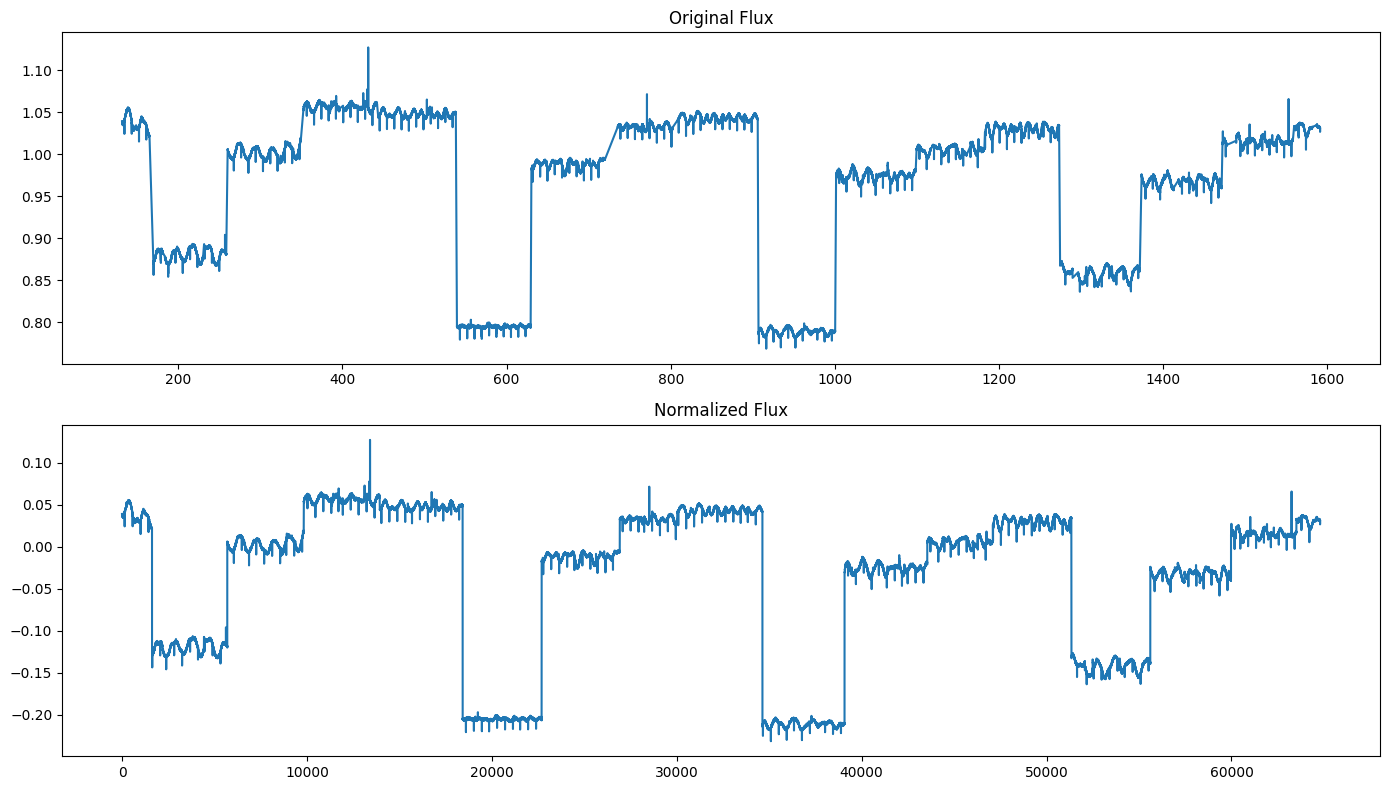

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_raw, flux_raw)
axes[0].set_title("Original Flux")

axes[1].plot(flux_norm)
axes[1].set_title("Normalized Flux")

plt.tight_layout()
plt.show()


In [53]:
# Step 3: clip outliers
flux_clip = clip_flux(flux_norm) if flux_norm is not None else None

print("Clipped flux length:", None if flux_clip is None else len(flux_clip))
print("First 10 clipped values:", None if flux_clip is None else flux_clip[:10])


Clipped flux length: 64795
First 10 clipped values: [0.03921509 0.03833592 0.03877485 0.03814089 0.03773725 0.0385232
 0.0386107  0.03823185 0.03932118 0.03721166]


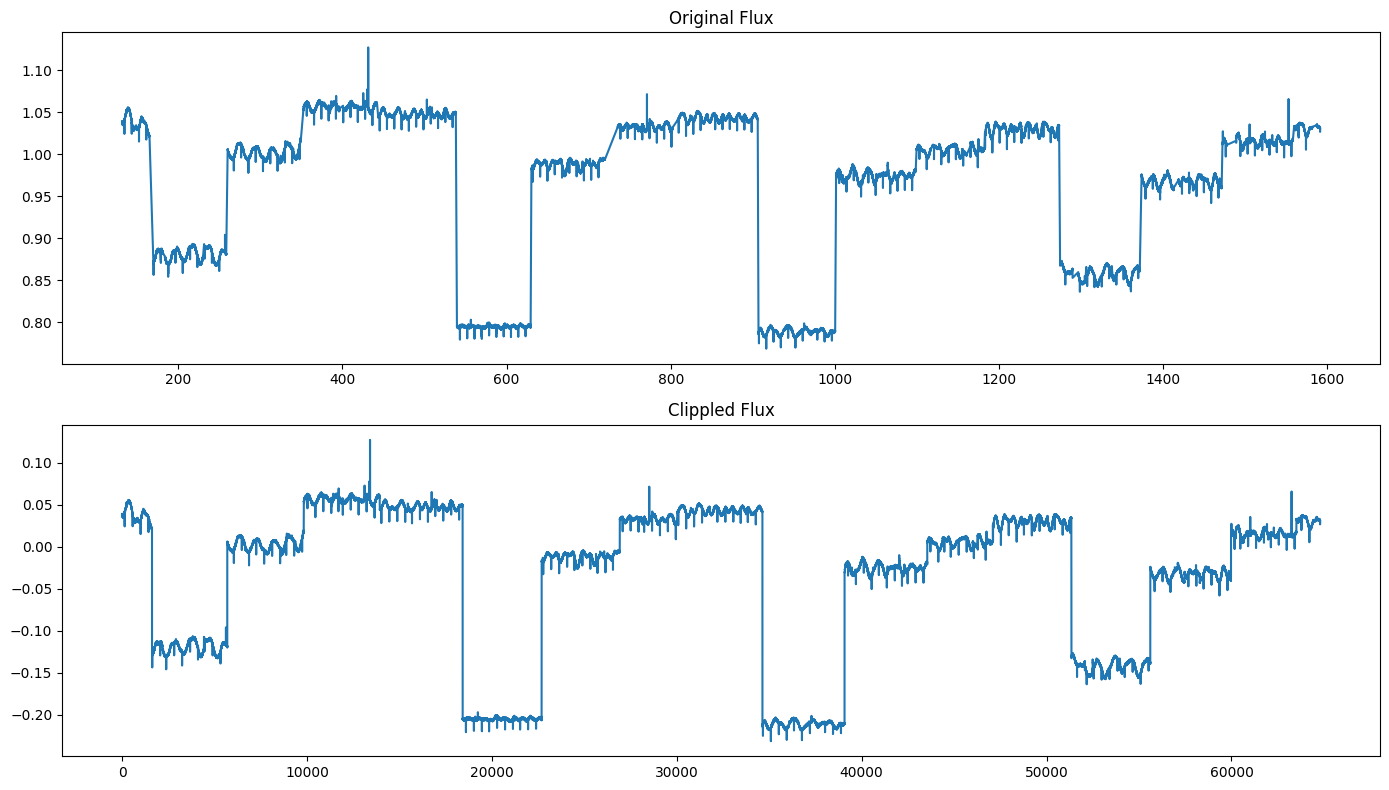

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_raw, flux_raw)
axes[0].set_title("Original Flux")

axes[1].plot(flux_clip)
axes[1].set_title("Clippled Flux")

plt.tight_layout()
plt.show()


In [55]:
# Step 4: resample to fixed length
seq_len = 2000
flux_resampled = resample_to_fixed_length(time_clean, flux_clip, seq_len=seq_len) if flux_clip is not None else None

print("Resampled length:", None if flux_resampled is None else len(flux_resampled))
print("Last 10 resampled values:", None if flux_resampled is None else flux_resampled[-10:])


Resampled length: 2000
Last 10 resampled values: [0.03389005 0.03418187 0.03447368 0.03476549 0.03368877 0.03188104
 0.03239324 0.03239997 0.03178225 0.03110564]


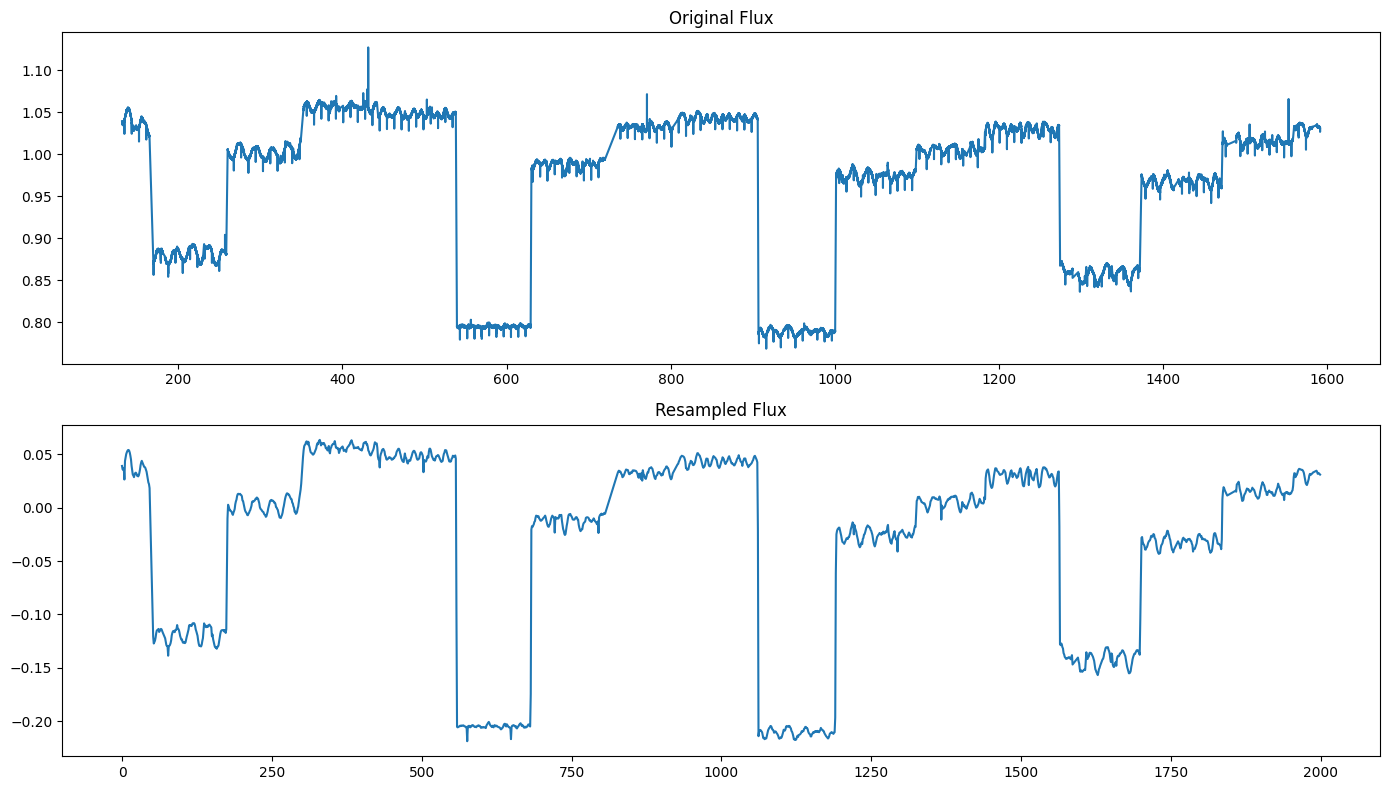

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_raw, flux_raw)
axes[0].set_title("Original Flux")

axes[1].plot(flux_resampled)
axes[1].set_title("Resampled Flux")

plt.tight_layout()
plt.show()


In [57]:
# Step 5: standardize final sequence
flux_std = standardize_flux(flux_resampled) if flux_resampled is not None else None

print("Final standardized length:", None if flux_std is None else len(flux_std))
print("First 10 standardized values:", None if flux_std is None else flux_std[:10])


Final standardized length: 2000
First 10 standardized values: [0.8206083  0.7839569  0.7783318  0.79349196 0.6740053  0.8744996
 0.9097158  0.9482466  0.96784663 0.9830672 ]


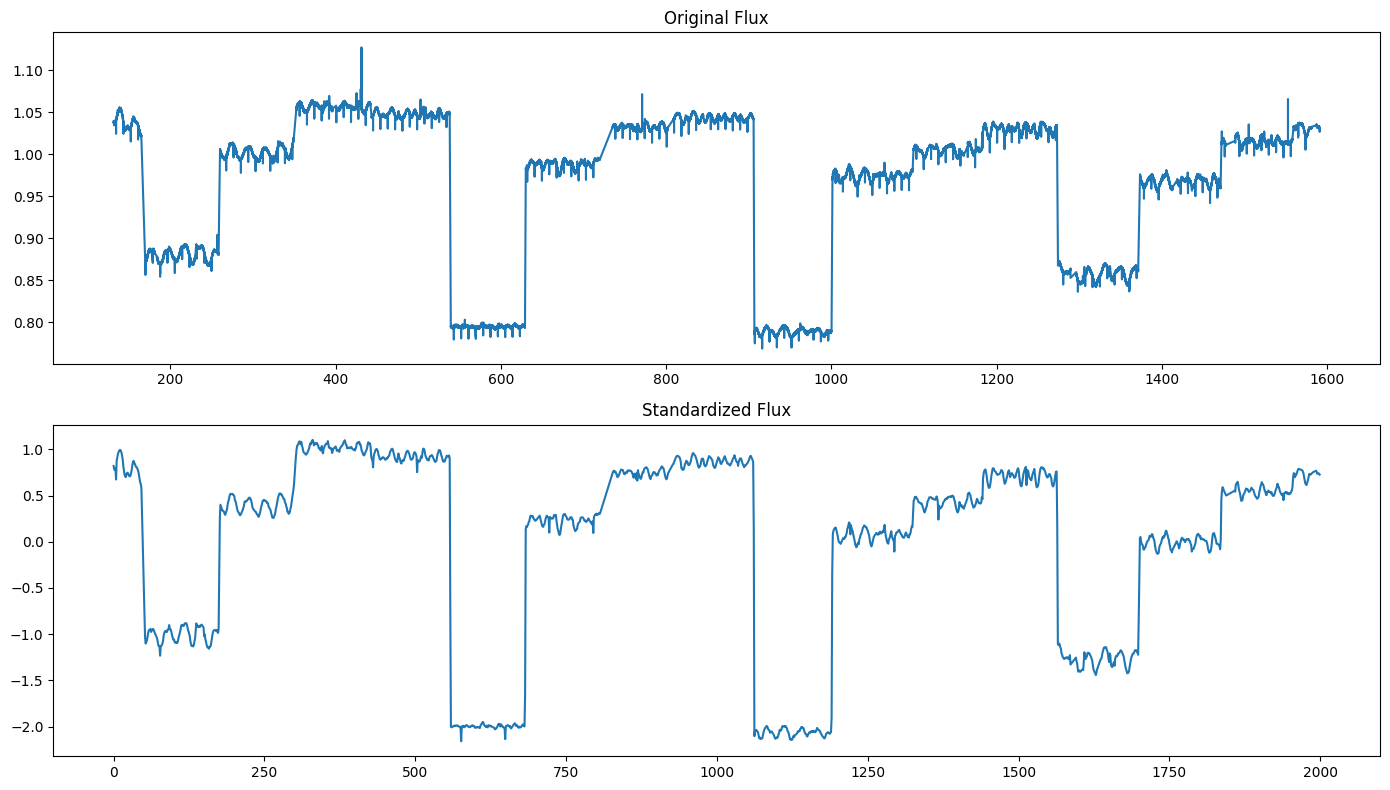

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_raw, flux_raw)
axes[0].set_title("Original Flux")

axes[1].plot(flux_std)
axes[1].set_title("Standardized Flux")

plt.tight_layout()
plt.show()


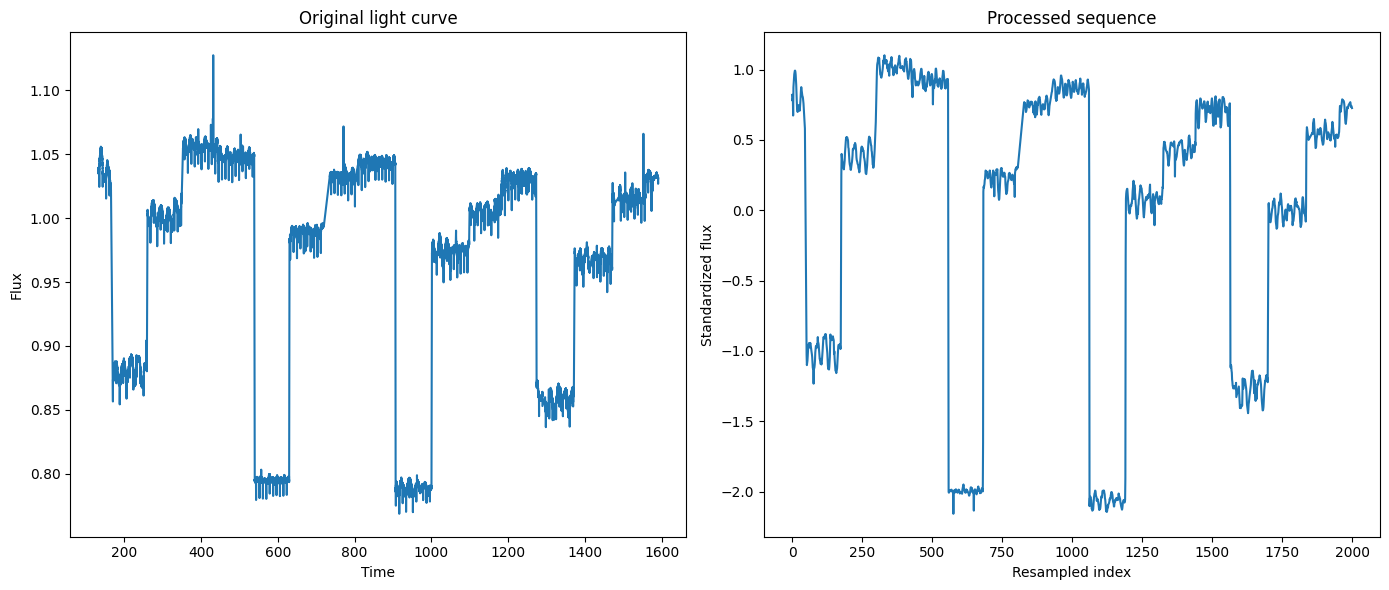

In [61]:
# Plot raw vs final processed sequence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(time_raw, flux_raw)
axes[0].set_title("Original light curve")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Flux")

if flux_std is not None:
    axes[1].plot(np.arange(len(flux_std)), flux_std)
axes[1].set_title("Processed sequence")
axes[1].set_xlabel("Resampled index")
axes[1].set_ylabel("Standardized flux")

plt.tight_layout()
plt.show()


In [ ]:
x = preprocess_light_curve(row["time"], row["flux"], seq_len=seq_len)
print("Final model input shape:", None if x is None else x.shape)
print("First 20 values:", None if x is None else x[:20])


Final model input shape: (2000,)
First 20 values: [0.8206083  0.7839569  0.7783318  0.79349196 0.6740053  0.8744996
 0.9097158  0.9482466  0.96784663 0.9830672  0.9925681  0.99352837
 0.98460275 0.9639699  0.93066794 0.89085215 0.8213603  0.7732982
 0.7264068  0.7167166 ]


---

In [63]:
df_processed = preprocess_dataframe(df, seq_len=2000)

print(len(df), "original rows")
print(len(df_processed), "usable rows after preprocessing")


{'KIC': 757450, 'x': array([0.8206083 , 0.7839569 , 0.7783318 , ..., 0.74195814, 0.7348294 ,
       0.7270209 ], shape=(2000,), dtype=float32), 'label': 0}
{'KIC': 892772, 'x': array([0.7126853 , 0.7079079 , 0.692986  , ..., 0.72527665, 0.7144841 ,
       0.72999847], shape=(2000,), dtype=float32), 'label': 2}
{'KIC': 1026032, 'x': array([1.1230941 , 1.1223437 , 1.1345929 , ..., 0.9415168 , 0.95014155,
       0.93161166], shape=(2000,), dtype=float32), 'label': 1}
{'KIC': 1026957, 'x': array([1.2582622 , 1.239024  , 1.2391576 , ..., 0.8728502 , 0.87960905,
       0.90102506], shape=(2000,), dtype=float32), 'label': 0}
{'KIC': 1027438, 'x': array([1.5399742, 1.5530251, 1.5460099, ..., 0.8049847, 0.8123927,
       0.8161338], shape=(2000,), dtype=float32), 'label': 2}
15606 original rows
15604 usable rows after preprocessing


In [64]:
df_processed


,KIC,x,label
0,757450,"[0.8206083, 0.7839569, 0.7783318, 0.79349196, ...",0
1,892772,"[0.7126853, 0.7079079, 0.692986, 0.7034703, 0....",2
2,1026032,"[1.1230941, 1.1223437, 1.1345929, 0.77730197, ...",1
3,1026957,"[1.2582622, 1.239024, 1.2391576, 1.2365696, 1....",0
4,1027438,"[1.5399742, 1.5530251, 1.5460099, 1.5429986, 1...",2
...,...,...,...
15599,202140012,"[-2.218767, -2.0478866, -1.8988385, -1.8245254...",3
15600,202140013,"[-1.8934886, -1.7278678, -1.6119652, -1.539871...",3
15601,202140059,"[1.5964152, 1.0933545, 0.5222775, 0.029452763,...",2
15602,202140094,"[1.6543092, 1.7366302, 1.926489, 1.561374, 0.8...",2


In [66]:
df_processed.to_parquet(r"../model-building/local-assets/PREPROCESSED_FLUX_TCN_INPUT.parquet")
